# Decision Trees in Regression
Decision trees work in regressions by making splits in the data, and getting the average of the data points for a particular feature. In a simple one-feature model, this would be visualized as the average of the data points for the `x` values within a range of a split.

In [3]:
import pandas as pd

penguins = pd.read_csv("../4 Linear Models/penguins.csv")
penguins.dropna(inplace=True)
feature_name = "flipper_length_mm"
target_name = "body_mass_g"

In [4]:
X_train, y_train = penguins[[feature_name]], penguins[target_name]

In [5]:
import numpy as np

X_test = pd.DataFrame(
    np.arange(X_train[feature_name].min(), X_train[feature_name].max(), 1),
    columns=[feature_name],
)

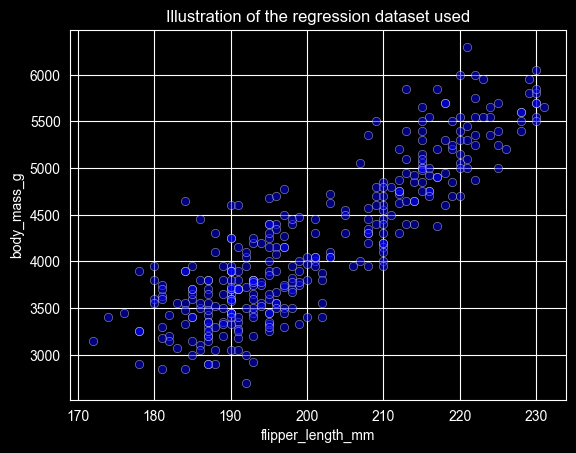

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=penguins,
    x=feature_name,
    y=target_name,
    color="blue",
    alpha=0.5
)
_ = plt.title("Illustration of the regression dataset used")

First, we illustrate the difference between a linear model and a decision tree.

In [7]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
target_predicted = linear_model.predict(X_test)

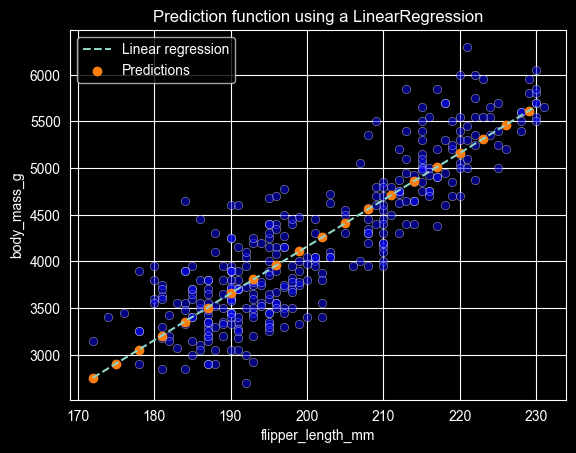

In [9]:
ax = sns.scatterplot(
    data=penguins, x=feature_name, y=target_name, color="blue", alpha=0.5
)
plt.plot(
    X_test[feature_name],
    target_predicted,
    label="Linear regression",
    linestyle="--",
)
plt.scatter(
    X_test[::3],
    target_predicted[::3],
    label="Predictions",
    color="tab:orange",
)
plt.legend()
_ = plt.title("Prediction function using a LinearRegression")

Contrary to linear models, decision trees are **non-parametric models**; they do not make assumptions about the way data is distributed.

As can be seen by the decision tree below, it does not assume a distribution for the data and instead, the prediction is split into two partitions.

In [10]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=1)
tree.fit(X_train, y_train)
target_predicted = tree.predict(X_test)

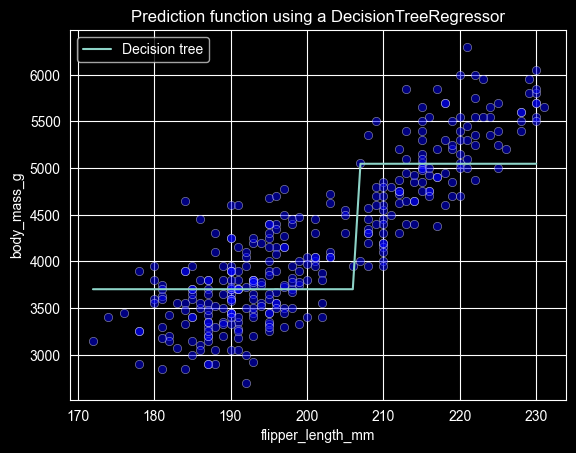

In [11]:
sns.scatterplot(
    data=penguins, x=feature_name, y=target_name, color="blue", alpha=0.5
)
plt.plot(X_test[feature_name], target_predicted, label="Decision tree")
plt.legend()
_ = plt.title("Prediction function using a DecisionTreeRegressor")

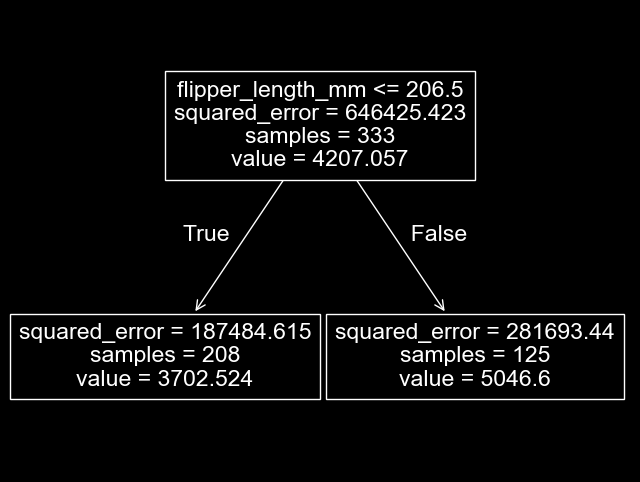

In [12]:
from sklearn.tree import plot_tree

_, ax = plt.subplots(figsize=(8, 6))
_ = plot_tree(tree, feature_names=[feature_name], ax=ax)

By increasing the depth of the tree, we get more complex decision boundaries.

In [14]:
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X_train, y_train)
target_predicted = tree.predict(X_test)

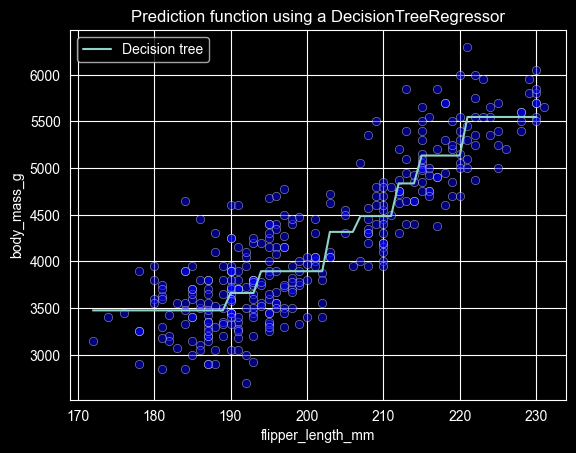

In [15]:
sns.scatterplot(
    data=penguins, x=feature_name, y=target_name, color="blue", alpha=0.5
)
plt.plot(X_test[feature_name], target_predicted, label="Decision tree")
plt.legend()
_ = plt.title("Prediction function using a DecisionTreeRegressor")